In [1]:
# Phase 6 – SR Design | Cell 1: Setup + Load

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")

OUT_DIR  = PROJECT / "outputs" / "phase6"
OUT_DATA = OUT_DIR / "data"
OUT_TAB  = OUT_DIR / "tables"
OUT_FIG  = OUT_DIR / "figures"
for d in [OUT_DATA, OUT_TAB, OUT_FIG]:
    d.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Phase 6 – SR Design | Cell 1")
print("=" * 60)
print(f"Timestamp    : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Project Root : {PROJECT}")
print(f"Outputs      : {OUT_DIR}")

fm = pd.read_pickle(PROJECT / "outputs" / "phase5" / "data" / "feature_matrix.pkl")
print(f"\nFeature Matrix: {fm.shape}")
print(f"Columns sample: {list(fm.columns[:12])}")
print(f"Years: {fm['year'].min()} – {fm['year'].max()} | Countries: {fm['iso2'].nunique()}")

print("\nCell 1 completed successfully.")

Phase 6 – SR Design | Cell 1
Timestamp    : 2026-09-27 08:16:55
Project Root : D:\univercity\omid_project\economics_project
Outputs      : D:\univercity\omid_project\economics_project\outputs\phase6

Feature Matrix: (378, 36)
Columns sample: ['year', 'iso2', 'in_strength', 'out_strength', 'betweenness', 'closeness', 'pagerank', 'eigenvector', 'katz', 'density', 'diameter', 'clustering']
Years: 2000 – 2020 | Countries: 18

Cell 1 completed successfully.


In [2]:
# Phase 6 – SR Design | Cell 2: Construct Structural Resilience Score

from pathlib import Path
import pandas as pd
import numpy as np

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase6" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase6" / "tables"

print("=" * 60)
print("Phase 6 – SR Design | Cell 2: Construct SR")
print("=" * 60)

fm = pd.read_pickle(PROJECT / "outputs" / "phase5" / "data" / "feature_matrix.pkl").copy()

# Centrality set for SR
CENT_COLS = ["pagerank", "betweenness", "closeness", "in_strength", "out_strength", "katz"]

# ---- min-max normalize within each year ----
for col in CENT_COLS:
    fm[f"{col}_n"] = fm.groupby("year")[col].transform(
        lambda s: (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else 0.0
    )

norm_cols = [f"{c}_n" for c in CENT_COLS]

# ---- SR equal weights (baseline) ----
# SR = (1/K) * sum hat{c}_k
fm["SR_equal"] = fm[norm_cols].mean(axis=1)

# ---- SR weighted with alpha, beta, gamma style ----
# Map: alpha->PageRank, beta->Betweenness, gamma->Closeness,
#      delta->InStrength, epsilon->OutStrength, zeta->Katz
# Default: equal → 1/6 each (matches oil-style weighted form with sum=1)
weights = {
    "pagerank_n": 1/6,      # alpha
    "betweenness_n": 1/6,   # beta
    "closeness_n": 1/6,     # gamma
    "in_strength_n": 1/6,   # delta
    "out_strength_n": 1/6,  # epsilon
    "katz_n": 1/6,          # zeta
}
assert abs(sum(weights.values()) - 1.0) < 1e-9

fm["SR"] = 0.0
for col, w in weights.items():
    fm["SR"] += w * fm[col]

# Keep SR_equal for comparison; main score = SR (equal by default)
print("Weight scheme (alpha,beta,gamma,...):")
for k, v in weights.items():
    print(f"  {k}: {v:.4f}")

print(f"\nSR records: {len(fm)}")
print(fm[["year", "iso2", "country_jst", "SR", "SR_equal"]].head(10).to_string(index=False))

# long and wide
sr_long = fm[["year", "iso2", "iso3", "country_jst", "SR", "SR_equal"] + norm_cols].copy()
sr_wide = sr_long.pivot(index="year", columns="iso2", values="SR")

sr_long.to_pickle(OUT_DATA / "sr_long.pkl")
sr_wide.to_pickle(OUT_DATA / "sr_wide.pkl")
sr_long.to_csv(OUT_TAB / "sr_long.csv", index=False)
sr_wide.to_csv(OUT_TAB / "sr_wide.csv")

# save weight definition
pd.DataFrame([{"component": k, "weight": v} for k, v in weights.items()]).to_csv(
    OUT_TAB / "sr_weights.csv", index=False
)

print(f"\nSR wide shape: {sr_wide.shape}")
print(f"Saved → {OUT_DATA / 'sr_long.pkl'}")
print("\nCell 2 completed successfully.")

Phase 6 – SR Design | Cell 2: Construct SR
Weight scheme (alpha,beta,gamma,...):
  pagerank_n: 0.1667
  betweenness_n: 0.1667
  closeness_n: 0.1667
  in_strength_n: 0.1667
  out_strength_n: 0.1667
  katz_n: 0.1667

SR records: 378
 year iso2 country_jst       SR  SR_equal
 2000   AU   Australia 0.208299  0.208299
 2000   BE     Belgium 0.261662  0.261662
 2000   CA      Canada 0.423172  0.423172
 2000   CH Switzerland 0.231929  0.231929
 2000   DE     Germany 0.772372  0.772372
 2000   DK     Denmark 0.206170  0.206170
 2000   ES       Spain 0.333343  0.333343
 2000   FI     Finland 0.093718  0.093718
 2000   FR      France 0.504458  0.504458
 2000   GB          UK 0.515447  0.515447

SR wide shape: (21, 18)
Saved → D:\univercity\omid_project\economics_project\outputs\phase6\data\sr_long.pkl

Cell 2 completed successfully.


Phase 6 – SR Design | Cell 3: Ranking
--- Overall SR Ranking ---
iso2 country_jst  mean_SR   std_SR  median_SR  rank
  DE     Germany 0.774005 0.026558   0.770838     1
  US         USA 0.768618 0.025711   0.764272     2
  FR      France 0.426983 0.041310   0.428559     3
  GB          UK 0.422847 0.027089   0.417731     4
  CA      Canada 0.381664 0.026146   0.391202     5
  NL Netherlands 0.323275 0.038809   0.316301     6
  IT       Italy 0.303068 0.030408   0.302697     7
  BE     Belgium 0.303028 0.049221   0.317615     8
  JP       Japan 0.294543 0.043337   0.281049     9
  ES       Spain 0.282171 0.023542   0.280585    10
  CH Switzerland 0.263088 0.025269   0.269423    11
  IE     Ireland 0.233852 0.026809   0.243979    12
  PT    Portugal 0.149243 0.043881   0.153150    13
  SE      Sweden 0.143510 0.033210   0.139328    14
  FI     Finland 0.119706 0.048495   0.126624    15
  AU   Australia 0.104839 0.032205   0.100533    16
  DK     Denmark 0.080779 0.039992   0.062626    17

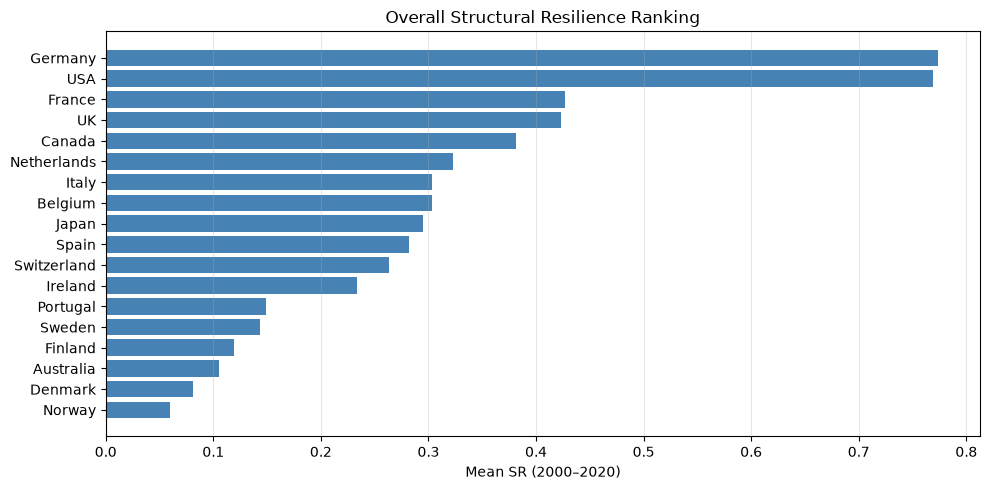

Saved → D:\univercity\omid_project\economics_project\outputs\phase6\figures\sr_overall_ranking.png

Cell 3 completed successfully.


In [3]:
# Phase 6 – SR Design | Cell 3: Ranking + Critical Nodes

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase6" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase6" / "tables"
OUT_FIG  = PROJECT / "outputs" / "phase6" / "figures"

print("=" * 60)
print("Phase 6 – SR Design | Cell 3: Ranking")
print("=" * 60)

sr = pd.read_pickle(OUT_DATA / "sr_long.pkl")

# Overall ranking by mean SR
overall = sr.groupby(["iso2", "country_jst"], as_index=False).agg(
    mean_SR=("SR", "mean"),
    std_SR=("SR", "std"),
    median_SR=("SR", "median"),
)
overall["rank"] = overall["mean_SR"].rank(ascending=False, method="min").astype(int)
overall = overall.sort_values("rank")

print("--- Overall SR Ranking ---")
print(overall.to_string(index=False))
overall.to_csv(OUT_TAB / "sr_overall_ranking.csv", index=False)

# Yearly ranking sample
yearly = sr.groupby(["year", "iso2", "country_jst"], as_index=False)["SR"].mean()
yearly["rank_year"] = yearly.groupby("year")["SR"].rank(ascending=False, method="min").astype(int)
yearly.to_csv(OUT_TAB / "sr_yearly_ranking.csv", index=False)

print("\n--- Sample yearly SR (2000) ---")
print(yearly[yearly["year"] == 2000].sort_values("rank_year").head(10).to_string(index=False))

# Bar chart overall
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(overall["country_jst"], overall["mean_SR"], color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Mean SR (2000–2020)")
ax.set_title("Overall Structural Resilience Ranking")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "sr_overall_ranking.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_FIG / 'sr_overall_ranking.png'}")

print("\nCell 3 completed successfully.")

Phase 6 – SR Design | Cell 4: Merge + Trends
Feature Matrix + SR shape: (378, 38)

--- Yearly SR (sample) ---
country_jst  Australia  Belgium  Canada  Denmark  Finland  France  Germany  Ireland  Italy  Japan  Netherlands  Norway  Portugal  Spain  Sweden  Switzerland     UK    USA
year                                                                                                                                                                      
2000             0.208    0.262   0.423    0.206    0.094   0.504    0.772    0.182  0.386  0.464        0.307   0.169     0.041  0.333   0.268        0.232  0.515  0.863
2001             0.089    0.328   0.414    0.069    0.085   0.417    0.733    0.188  0.291  0.324        0.307   0.026     0.208  0.241   0.088        0.192  0.428  0.793
2002             0.081    0.282   0.395    0.089    0.091   0.429    0.742    0.283  0.311  0.330        0.238   0.078     0.189  0.272   0.136        0.272  0.442  0.796
2003             0.065    0.297   0

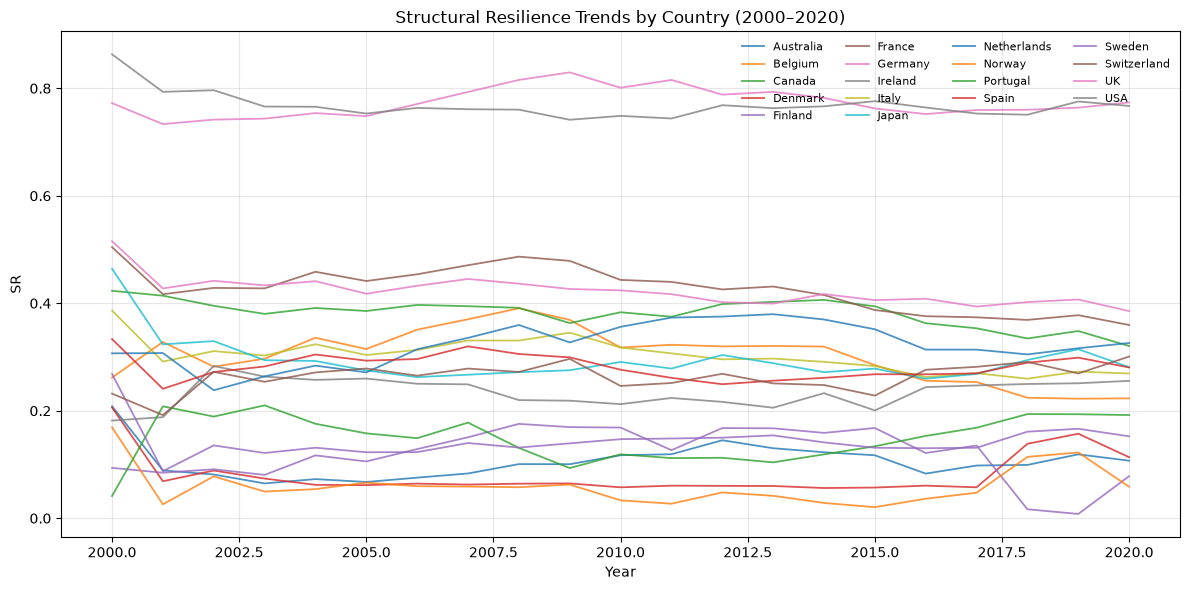


Saved → D:\univercity\omid_project\economics_project\outputs\phase6\data\feature_matrix_with_sr.pkl

Cell 4 completed successfully.
PHASE 6 COMPLETED.


In [4]:
# Phase 6 – SR Design | Cell 4: Merge SR + Temporal Trends

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase6" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase6" / "tables"
OUT_FIG  = PROJECT / "outputs" / "phase6" / "figures"

print("=" * 60)
print("Phase 6 – SR Design | Cell 4: Merge + Trends")
print("=" * 60)

fm = pd.read_pickle(PROJECT / "outputs" / "phase5" / "data" / "feature_matrix.pkl")
sr = pd.read_pickle(OUT_DATA / "sr_long.pkl")

fm2 = fm.merge(
    sr[["year", "iso2", "SR", "SR_equal"]],
    on=["year", "iso2"], how="left"
)
print(f"Feature Matrix + SR shape: {fm2.shape}")

fm2.to_pickle(OUT_DATA / "feature_matrix_with_sr.pkl")
fm2.to_csv(OUT_TAB / "feature_matrix_with_sr.csv", index=False)

# Yearly mean SR by country (for trends)
yearly = sr.groupby(["year", "country_jst"], as_index=False)["SR"].mean()
pivot = yearly.pivot(index="year", columns="country_jst", values="SR")

print("\n--- Yearly SR (sample) ---")
print(pivot.head(5).round(3).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
for col in pivot.columns:
    ax.plot(pivot.index, pivot[col], alpha=0.8, linewidth=1.3, label=col)
ax.set_xlabel("Year")
ax.set_ylabel("SR")
ax.set_title("Structural Resilience Trends by Country (2000–2020)")
ax.legend(ncol=4, fontsize=8, frameon=False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "sr_temporal_trends.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSaved → {OUT_DATA / 'feature_matrix_with_sr.pkl'}")
print("\nCell 4 completed successfully.")
print("PHASE 6 COMPLETED.")

In [5]:
# Phase 6 – Fix | Cell 5: Thresholded networks + SR

from pathlib import Path
import pandas as pd
import numpy as np
import networkx as nx
import pickle

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase6" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase6" / "tables"

print("=" * 60)
print("Phase 6 – Fix | Cell 5: Thresholded Topology SR")
print("=" * 60)

with open(PROJECT / "outputs" / "phase4" / "data" / "temporal_trade_networks_clean.pkl", "rb") as f:
    nets = pickle.load(f)

cw = pd.read_pickle(PROJECT / "outputs" / "phase1" / "data" / "country_crosswalk.pkl")
iso2_list = cw["iso2"].tolist()

# Keep edges above yearly median weight (topology becomes incomplete)
records = []
meta = []
thr_nets = {}

for y, g in sorted(nets.items(), key=lambda x: x[0]):
    weights = [d["weight"] for _, _, d in g.edges(data=True)]
    thr = float(np.median(weights)) if weights else 0.0
    gt = nx.DiGraph()
    gt.add_nodes_from(iso2_list)
    for u, v, d in g.edges(data=True):
        if d["weight"] >= thr:
            gt.add_edge(u, v, weight=float(d["weight"]))
    thr_nets[y] = gt

    dens = nx.density(gt)
    meta.append({"year": y, "threshold": thr, "n_edges": gt.number_of_edges(), "density": dens})

    # centralities on thresholded graph
    in_s = dict(gt.in_degree(weight="weight"))
    out_s = dict(gt.out_degree(weight="weight"))
    g_dist = gt.copy()
    for u, v, d in g_dist.edges(data=True):
        w = float(d.get("weight", 0.0))
        d["distance"] = 1.0 / w if w > 0 else 1e12
    try:
        bt = nx.betweenness_centrality(g_dist, weight="distance", normalized=True)
    except Exception:
        bt = {n: 0.0 for n in gt.nodes()}
    try:
        cl = nx.closeness_centrality(g_dist, distance="distance")
    except Exception:
        cl = {n: 0.0 for n in gt.nodes()}
    try:
        pr = nx.pagerank(gt, weight="weight", max_iter=500)
    except Exception:
        pr = {n: 1.0/len(iso2_list) for n in iso2_list}
    try:
        gu = gt.to_undirected()
        ev = nx.eigenvector_centrality_numpy(gu, weight="weight") if gu.number_of_edges() else {n: 0.0 for n in iso2_list}
    except Exception:
        ev = {n: 0.0 for n in iso2_list}
    try:
        kz = nx.katz_centrality_numpy(gt, weight="weight", alpha=1e-4) if gt.number_of_edges() else {n: 0.0 for n in iso2_list}
    except Exception:
        kz = {n: 0.0 for n in iso2_list}

    for n in iso2_list:
        records.append({
            "year": y, "iso2": n,
            "in_strength": float(in_s.get(n, 0.0)),
            "out_strength": float(out_s.get(n, 0.0)),
            "betweenness": float(bt.get(n, 0.0)),
            "closeness": float(cl.get(n, 0.0)),
            "pagerank": float(pr.get(n, 0.0)),
            "eigenvector": float(ev.get(n, 0.0)),
            "katz": float(kz.get(n, 0.0)),
        })

cent_thr = pd.DataFrame(records)
meta_df = pd.DataFrame(meta)
print("--- Thresholded network density (sample) ---")
print(meta_df.head(8).to_string(index=False))
print(f"Density range: {meta_df['density'].min():.3f} – {meta_df['density'].max():.3f}")

# SR on thresholded centralities
CENT = ["pagerank", "betweenness", "closeness", "in_strength", "out_strength", "katz"]
for c in CENT:
    cent_thr[f"{c}_n"] = cent_thr.groupby("year")[c].transform(
        lambda s: (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else 0.0
    )
cent_thr["SR_thr"] = cent_thr[[f"{c}_n" for c in CENT]].mean(axis=1)

cent_thr.to_pickle(OUT_DATA / "sr_thresholded_long.pkl")
cent_thr.to_csv(OUT_TAB / "sr_thresholded_long.csv", index=False)
meta_df.to_csv(OUT_TAB / "threshold_network_meta.csv", index=False)
with open(OUT_DATA / "temporal_networks_thresholded.pkl", "wb") as f:
    pickle.dump(thr_nets, f)

print(f"\nSaved thresholded SR + networks")
print("\nCell 5 completed successfully.")

Phase 6 – Fix | Cell 5: Thresholded Topology SR
--- Thresholded network density (sample) ---
 year    threshold  n_edges  density
 2000 2762360.1050      153      0.5
 2001 2595472.0635      153      0.5
 2002 2714386.6825      153      0.5
 2003 3220269.9635      153      0.5
 2004 3640867.1635      153      0.5
 2005 3896916.6845      153      0.5
 2006 4441059.0220      153      0.5
 2007 4754055.0550      153      0.5
Density range: 0.500 – 0.500

Saved thresholded SR + networks

Cell 5 completed successfully.


In [6]:
# Phase 6 – Fix | Cell 6: Weight sensitivity (alpha, beta, gamma,...)

from pathlib import Path
import pandas as pd
import numpy as np
from itertools import product

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase6" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase6" / "tables"

print("=" * 60)
print("Phase 6 – Fix | Cell 6: Weight Sensitivity")
print("=" * 60)

# Use thresholded centralities (non-complete topology)
df = pd.read_pickle(OUT_DATA / "sr_thresholded_long.pkl").copy()
CENT = ["pagerank", "betweenness", "closeness", "in_strength", "out_strength", "katz"]
norm_cols = [f"{c}_n" for c in CENT]

# Ensure norms exist
for c in CENT:
    if f"{c}_n" not in df.columns:
        df[f"{c}_n"] = df.groupby("year")[c].transform(
            lambda s: (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else 0.0
        )

# Baseline equal
df["SR_equal"] = df[norm_cols].mean(axis=1)

# Sensitivity grid: vary alpha,beta,gamma on PR, BC, CC; rest share remaining mass equally
grid = [0.1, 0.2, 1/3, 0.4]
rows = []
rank_corr_rows = []

base_rank = df.groupby("iso2")["SR_equal"].mean().rank(ascending=False)

for a, b, g in product(grid, repeat=3):
    if a + b + g > 0.95:
        continue
    rest = 1.0 - (a + b + g)
    w = {
        "pagerank_n": a,
        "betweenness_n": b,
        "closeness_n": g,
        "in_strength_n": rest / 3,
        "out_strength_n": rest / 3,
        "katz_n": rest / 3,
    }
    sr = sum(w[c] * df[c] for c in norm_cols)
    mean_by_country = df.assign(SRw=sr).groupby("iso2")["SRw"].mean()
    rk = mean_by_country.rank(ascending=False)
    # Spearman vs equal-weight ranking
    aligned = pd.concat([base_rank, rk], axis=1, keys=["base", "alt"]).dropna()
    corr = aligned["base"].corr(aligned["alt"], method="spearman")
    rank_corr_rows.append({"alpha": a, "beta": b, "gamma": g, "rest_each": rest/3, "spearman_vs_equal": corr})

sens = pd.DataFrame(rank_corr_rows).sort_values("spearman_vs_equal", ascending=False)
print("--- Top robust weight schemes (Spearman vs equal) ---")
print(sens.head(10).to_string(index=False))
print(f"\nMin Spearman: {sens['spearman_vs_equal'].min():.3f} | Max: {sens['spearman_vs_equal'].max():.3f}")

sens.to_csv(OUT_TAB / "sr_weight_sensitivity.csv", index=False)

# Choose official scheme: equal weights (most transparent) + record sensitivity summary
official = {
    "pagerank_n": 1/6, "betweenness_n": 1/6, "closeness_n": 1/6,
    "in_strength_n": 1/6, "out_strength_n": 1/6, "katz_n": 1/6,
}
df["SR"] = sum(official[c] * df[c] for c in norm_cols)

# Also store one alternative emphasizing strength (trade volume)
alt = {
    "pagerank_n": 0.1, "betweenness_n": 0.1, "closeness_n": 0.1,
    "in_strength_n": 0.35, "out_strength_n": 0.35, "katz_n": 0.0,
}
df["SR_strength_heavy"] = sum(alt[c] * df[c] for c in norm_cols)

df.to_pickle(OUT_DATA / "sr_thresholded_with_variants.pkl")
df.to_csv(OUT_TAB / "sr_thresholded_with_variants.csv", index=False)
pd.DataFrame([
    {"scheme": "official_equal", **official},
    {"scheme": "strength_heavy", **alt},
]).to_csv(OUT_TAB / "sr_official_weight_schemes.csv", index=False)

print("\nOfficial scheme: equal weights (1/6)")
print("Alternative scheme: strength-heavy saved as SR_strength_heavy")
print("Cell 6 completed successfully.")

Phase 6 – Fix | Cell 6: Weight Sensitivity
--- Top robust weight schemes (Spearman vs equal) ---
   alpha     beta  gamma  rest_each  spearman_vs_equal
0.200000 0.200000    0.1   0.166667           0.997936
0.100000 0.200000    0.2   0.166667           0.997936
0.333333 0.200000    0.1   0.122222           0.993808
0.333333 0.100000    0.1   0.155556           0.993808
0.400000 0.200000    0.1   0.100000           0.993808
0.100000 0.100000    0.2   0.200000           0.993808
0.200000 0.200000    0.2   0.133333           0.993808
0.400000 0.100000    0.1   0.133333           0.991744
0.100000 0.200000    0.1   0.200000           0.991744
0.100000 0.333333    0.1   0.155556           0.991744

Min Spearman: 0.967 | Max: 0.998

Official scheme: equal weights (1/6)
Alternative scheme: strength-heavy saved as SR_strength_heavy
Cell 6 completed successfully.


In [7]:
# Phase 6 – Fix | Cell 7: Hybrid multi-signal SR + Finalize

from pathlib import Path
import pandas as pd
import numpy as np

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase6" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase6" / "tables"

print("=" * 60)
print("Phase 6 – Fix | Cell 7: Hybrid SR + Finalize")
print("=" * 60)

thr = pd.read_pickle(OUT_DATA / "sr_thresholded_with_variants.pkl")
fm  = pd.read_pickle(PROJECT / "outputs" / "phase5" / "data" / "feature_matrix.pkl")
cw  = pd.read_pickle(PROJECT / "outputs" / "phase1" / "data" / "country_crosswalk.pkl")

# Network SR (thresholded, equal weights) — main structural score
net = thr[["year", "iso2", "SR", "SR_equal", "SR_strength_heavy"]].rename(
    columns={"SR": "SR_network", "SR_equal": "SR_network_equal",
             "SR_strength_heavy": "SR_network_strength"}
)

# Merge macro/credit/icio features
cols = [c for c in [
    "year", "iso2", "iso3", "country_jst",
    "rgdpmad", "debtgdp", "unemp", "iy",
    "credit_private_pct_gdp", "export_kusd", "trade_openness_kusd",
    "icio_output", "icio_hfce", "icio_ggfc"
] if c in fm.columns]
base = fm[cols].copy()

hyb = base.merge(net, on=["year", "iso2"], how="left")

# Normalize complementary signals within year (higher = more "capacity/resilience contribution")
# For unemp & debtgdp: invert so higher score = better
comp = {
    "rgdpmad": 1,
    "iy": 1,
    "credit_private_pct_gdp": 1,
    "export_kusd": 1,
    "trade_openness_kusd": 1,
    "icio_output": 1,
    "debtgdp": -1,   # invert
    "unemp": -1,     # invert
}
comp = {k: v for k, v in comp.items() if k in hyb.columns}

for col, sign in comp.items():
    x = hyb.groupby("year")[col].transform(lambda s: (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else 0.0)
    hyb[f"{col}_n"] = x if sign > 0 else (1.0 - x)

comp_n = [f"{c}_n" for c in comp.keys()]
hyb["SR_fundamentals"] = hyb[comp_n].mean(axis=1)

# Hybrid SR: 70% network structure + 30% fundamentals
hyb["SR"] = 0.7 * hyb["SR_network"].fillna(0) + 0.3 * hyb["SR_fundamentals"].fillna(0)
hyb["SR_network_only"] = hyb["SR_network"]
hyb["SR_hybrid"] = hyb["SR"]

# Rankings
overall = hyb.groupby(["iso2", "country_jst"], as_index=False).agg(
    mean_SR=("SR", "mean"),
    mean_SR_network=("SR_network", "mean"),
    mean_SR_fundamentals=("SR_fundamentals", "mean"),
)
overall["rank"] = overall["mean_SR"].rank(ascending=False, method="min").astype(int)
overall = overall.sort_values("rank")
print("--- Final Hybrid SR Ranking ---")
print(overall.to_string(index=False))

# Final feature matrix for next phases
final = fm.merge(
    hyb[["year", "iso2", "SR", "SR_network", "SR_network_strength",
         "SR_fundamentals", "SR_hybrid"]],
    on=["year", "iso2"], how="left"
)

final.to_pickle(OUT_DATA / "feature_matrix_with_sr_final.pkl")
final.to_csv(OUT_TAB / "feature_matrix_with_sr_final.csv", index=False)
hyb.to_pickle(OUT_DATA / "sr_hybrid_long.pkl")
hyb.to_csv(OUT_TAB / "sr_hybrid_long.csv", index=False)
overall.to_csv(OUT_TAB / "sr_final_ranking_hybrid.csv", index=False)

print(f"\nFinal FM shape: {final.shape}")
print("Saved feature_matrix_with_sr_final.pkl")
print("\nCell 7 completed successfully.")
print("PHASE 6 LIMITATIONS ADDRESSED.")

Phase 6 – Fix | Cell 7: Hybrid SR + Finalize
--- Final Hybrid SR Ranking ---
iso2 country_jst  mean_SR  mean_SR_network  mean_SR_fundamentals  rank
  US         USA 0.753498         0.767547              0.720715     1
  DE     Germany 0.712465         0.787430              0.537548     2
  GB          UK 0.428028         0.434640              0.412600     3
  FR      France 0.412597         0.436729              0.356287     4
  CA      Canada 0.375513         0.365147              0.399702     5
  JP       Japan 0.359467         0.321543              0.447958     6
  NL Netherlands 0.348005         0.321209              0.410528     7
  BE     Belgium 0.306280         0.287403              0.350327     8
  CH Switzerland 0.300486         0.235959              0.451049     9
  IE     Ireland 0.299569         0.211108              0.505978    10
  ES       Spain 0.290038         0.293336              0.282341    11
  IT       Italy 0.287800         0.297557              0.265033    12
